In [1]:
import os
from tqdm import tqdm

MODE   = 'test'
AV1ENC = '/home/zhaoy/AV1-Optimization/Bin/Release/SvtAv1EncApp'
QPs = list(range(32, 62, 5))
PRESET = 4
DEBUG  = False

In [2]:
import time

def enc_av1(width, height, yuv_dir, rlt_root, av1enc=AV1ENC, qps=QPs, preset=PRESET, debug=DEBUG):
    yuvs = [_ for _ in os.listdir(yuv_dir) if _.endswith('.yuv')]
    for yuv in tqdm(yuvs):
        yuv_path = os.path.join(yuv_dir, yuv)
        os.makedirs(f'{rlt_root}/log', exist_ok=True)
        os.makedirs(f'{rlt_root}/bin', exist_ok=True)
        os.makedirs(f'{rlt_root}/rec', exist_ok=True)
        
        for qp in qps:
            log_path = os.path.join(rlt_root, 'log', yuv.replace('.yuv', f'_qp{qp}_{PRESET}.log'))
            bin_path = os.path.join(rlt_root, 'bin', yuv.replace('.yuv', f'_qp{qp}_{PRESET}.bin'))
            rec_path = os.path.join(rlt_root, 'rec', yuv.replace('.yuv', f'_qp{qp}_{PRESET}.yuv'))
            
            cmd = f'{av1enc} -i {yuv_path} -w {width} -h {height} --tune 2 --preset {preset} --fps 30 --rc 0 --qp {qp} --enable-qm 1 --keyint 256 --hierarchical-levels 5 --enable-stat-report 1 --stat-file {log_path} -b {bin_path} -o {rec_path} --progress 0 &'
            os.system(cmd)
            if DEBUG:
                break
        time.sleep(1)

In [12]:
# import re

# def extract_av1_metrics(log_path):
#     with open(log_path, 'r') as f:
#         lines = f.readlines()
    
#     bpp, psnr_y, psnr_u, psnr_v = None, None, None, None
#     for line in reversed(lines):
#         if line.strip().startswith('Total Frames'):
#             idx = lines.index(line)
#             if idx + 1 < len(lines):
#                 vals = re.split(r'\s*\|\s*', lines[idx + 1].strip())
                
#                 psnr_values = re.findall(r'[\d\.]+', vals[0])
#                 ssim_values = re.findall(r'[\d\.]+', vals[2])
#                 y_psnr, u_psnr, v_psnr = map(float, psnr_values[-3:])
#                 y_ssim, u_ssim, v_ssim = map(float, ssim_values[:3])
                
#                 bitrate_match = re.search(r'([\d\.]+)\s*kbps', parts[3])
#                 if bitrate_match:
#                     bitrate = float(bitrate_match.group(1))
#                 else:
#                     raise Warning(f'Bitrate not found in line: {lines[idx + 1]}')
#                 yuv_psnr = (6 * y_psnr + u_psnr + v_psnr) / 8
#                 yuv_ssim = (6 * y_ssim + u_ssim + v_ssim) / 8
#                 break
    
#     return [bitrate, yuv_psnr, yuv_ssim]

In [4]:
''' 1. Touch and Go '''
yuv_root = '/data/ssd/zhaoy/datasets/TouchandGoDataset-v2/dataset-comp'
yuv_dir  = os.path.join(yuv_root, MODE, 'video', 'yuv')
rlt_root = '/data/ssd/zhaoy/datasets/TouchandGoDataset-v2/compressed/svtav1'

# enc_av1(width=640, height=480, yuv_dir=yuv_dir, rlt_root=rlt_root)

In [14]:
''' 2. Object Folder '''
yuv_root = '/data/ssd/zhaoy/datasets/ObjectFolder_1.0/dataset-comp'
yuv_dir  = os.path.join(yuv_root, MODE, 'video', 'yuv')
rlt_root = '/data/ssd/zhaoy/datasets/ObjectFolder_1.0/compressed/svtav1'

# enc_av1(width=120, height=160, yuv_dir=yuv_dir, rlt_root=rlt_root)

In [15]:
''' 3. SSVTP '''
yuv_root = '/data/ssd/zhaoy/datasets/SSVTP/dataset-comp'
yuv_dir  = os.path.join(yuv_root, MODE, 'video', 'yuv')
rlt_root = '/data/ssd/zhaoy/datasets/SSVTP/compressed/svtav1'

# enc_av1(width=240, height=320, yuv_dir=yuv_dir, rlt_root=rlt_root)

In [16]:
''' 4. YCB-Slide '''
yuv_root = '/data/ssd/zhaoy/datasets/YCB-Slide/dataset-comp'
yuv_dir  = os.path.join(yuv_root, MODE, 'video', 'yuv')
rlt_root = '/data/ssd/zhaoy/datasets/YCB-Slide/compressed/svtav1'

# enc_av1(width=240, height=320, yuv_dir=yuv_dir, rlt_root=rlt_root)

In [32]:
from metrics import calPSNR, calSSIM, calVMAF

def cal_metrics(rlt_root, orig_dir, width, height, cal_psnr=True, cal_ssim=True, cal_vmaf=False):
    metrics_dir = os.path.join(rlt_root, 'metrics')
    if cal_psnr:
        os.makedirs(f'{metrics_dir}/psnr', exist_ok=True)
    if cal_ssim:
        os.makedirs(f'{metrics_dir}/ssim', exist_ok=True)
    if cal_vmaf:
        os.makedirs(f'{metrics_dir}/vmaf', exist_ok=True)
    
    rec_dir = os.path.join(rlt_root, 'rec')
    for rec_file in os.listdir(rec_dir):
        rec_path  = os.path.join(rec_dir, rec_file)
        orig_path = os.path.join(orig_dir, rec_file.split('_qp')[0]+'.yuv')
        if cal_psnr:
            calPSNR(
                orig_path, rec_path, os.path.join(metrics_dir, 'psnr'), width=width, height=height, scale_width=width, scale_height=height, orig_fmt='yuv420p', rec_fmt='yuv420p'
            )
        if cal_ssim:
            calSSIM(
                orig_path, rec_path, os.path.join(metrics_dir, 'ssim'), width=width, height=height, scale_width=width, scale_height=height, orig_fmt='yuv420p', rec_fmt='yuv420p'
            )
        if cal_vmaf:
            calVMAF(
                orig_path, rec_path, os.path.join(metrics_dir, 'vmaf'), width=width, height=height, orig_fmt='yuv420p', rec_fmt='yuv420p'
            )

In [5]:
from msssim import calc_msssim_yuv

In [36]:
''' 1. Touch and Go '''
rlt_root = '/data/ssd/zhaoy/datasets/TouchandGoDataset-v2/compressed/svtav1'
orig_dir = '/data/ssd/zhaoy/datasets/TouchandGoDataset-v2/dataset-comp/test/video/yuv'
width, height = 640, 480
# cal_metrics(rlt_root=rlt_root, orig_dir=orig_dir, width=width, height=height)

In [20]:
''' 2. Object Folder '''
rlt_root = '/data/ssd/zhaoy/datasets/ObjectFolder_1.0/compressed/svtav1'
orig_dir = '/data/ssd/zhaoy/datasets/ObjectFolder_1.0/dataset-comp/test/video/yuv'
width, height = 160, 120
# cal_metrics(rlt_root=rlt_root, orig_dir=orig_dir, width=width, height=height)

In [21]:
''' 3. SSVTP '''
rlt_root = '/data/ssd/zhaoy/datasets/SSVTP/compressed/svtav1'
orig_dir = '/data/ssd/zhaoy/datasets/SSVTP/dataset-comp/test/video/yuv'
width, height = 240, 320
# cal_metrics(rlt_root=rlt_root, orig_dir=orig_dir, width=width, height=height)

In [22]:
''' 4. YCB-Slide '''
rlt_root = '/data/ssd/zhaoy/datasets/YCB-Slide/compressed/svtav1'
orig_dir = '/data/ssd/zhaoy/datasets/YCB-Slide/dataset-comp/test/video/yuv'
width, height = 240, 320
# cal_metrics(rlt_root=rlt_root, orig_dir=orig_dir, width=width, height=height)

In [37]:
def get_av1Info(log_path):
    with open(log_path, 'r') as f:
        lines = f.readlines()
    
    for line in reversed(lines):
        if line.strip().startswith('Total Frames'):
            idx = lines.index(line)
            if idx + 1 < len(lines):
                vals = re.split(r'\s*\|\s*', lines[idx + 1].strip())
                
                nframes = int(vals[0].split()[0])
                psnr_values = re.findall(r'[\d\.]+', vals[0])
                ssim_values = re.findall(r'[\d\.]+', vals[2])
                y_psnr, u_psnr, v_psnr = map(float, psnr_values[-3:])
                y_ssim, u_ssim, v_ssim = map(float, ssim_values[:3])
                
                bitrate_match = re.search(r'([\d\.]+)\s*kbps', vals[3])
                if bitrate_match:
                    bitrate = float(bitrate_match.group(1))
                else:
                    raise Warning(f'Bitrate not found in line: {lines[idx + 1]}')
                yuv_psnr = (6 * y_psnr + u_psnr + v_psnr) / 8
                yuv_ssim = (6 * y_ssim + u_ssim + v_ssim) / 8
                break
    
    return [bitrate, nframes, yuv_psnr, yuv_ssim]

# log_path = '/data/ssd/zhaoy/datasets/SSVTP/compressed/svtav1/log/SSVTP_qp27_4.log'
# get_av1Info(log_path)

In [28]:
import re
import pandas as pd
from metrics import getPSNR, getSSIM, getVMAF

def get_metrics(rlt_root, size, get_psnr=True, get_ssim=True, get_vmaf=False):
    log_dir = os.path.join(rlt_root, 'log')
    metrics_dir = os.path.join(rlt_root, 'metrics')
    
    allseqInfo = []
    for log_file in os.listdir(log_dir):
        log_path = os.path.join(log_dir, log_file)
        try:
            enc_info = get_av1Info(log_path)
        except Exception as e:
            continue
        bitrate, nframes = enc_info[0], enc_info[1]
        
        seq_name = log_file.split('_qp')[0]
        qp, preset = log_file.replace('.log', '').split('_qp')[1].split('_')
        qp = int(qp)
        columns = ['video_name', 'qp', 'preset', 'size', 'nframes', 'bitrate']
        row = [seq_name, qp, preset, size, nframes, bitrate]
        try:
            if get_psnr:
                psnr = getPSNR(os.path.join(metrics_dir, 'psnr', log_file.replace('log', 'txt')))
                row.append(psnr)
                columns.append('psnr')
            if get_ssim:
                ssim = getSSIM(os.path.join(metrics_dir, 'ssim', log_file.replace('log', 'txt')))
                row.append(ssim)
                columns.append('ssim')
            if get_vmaf:
                vmaf = getVMAF(os.path.join(metrics_dir, 'vmaf', log_file.replace('log', 'txt')))
                row.append(vmaf)
                columns.append('vmaf')
        except Exception as e:
            continue
        
        allseqInfo.append(row)
    allseqInfoDf = pd.DataFrame(allseqInfo, columns=columns)
    return allseqInfoDf
        

In [39]:
''' 1. Touch and Go '''
DATASET  = 'TouchandGoDataset-v2'
width, height = 640, 480

# rlt_root = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/svtav1'
# df = get_metrics(rlt_root=rlt_root, size=f'{width}x{height}')
# display(df)

# orig_dir = f'/data/ssd/zhaoy/datasets/{DATASET}/dataset-comp/test/video/yuv'
# rec_dir  = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/x265/rec'
# msssim_dict = {}  # key = (video_name, qp, preset)

# for rec_file in tqdm(os.listdir(rec_dir)):
#     if not rec_file.endswith('.yuv'):
#         continue
#     video_name, qp, preset = rec_file.replace('.yuv', '').split('_')
#     qp = int(qp.replace('qp', ''))
#     rec_path  = os.path.join(rec_dir, rec_file)
#     orig_path = os.path.join(orig_dir, f'{video_name}.yuv')
#     msssim_val = calc_msssim_yuv(orig_path, rec_path, width=width, height=height)
#     msssim_dict[(video_name, qp)] = msssim_val
    
# print(msssim_dict)
# df['msssim'] = df.apply(
#     lambda row: msssim_dict.get((row['video_name'], row['qp']), None),
#     axis=1
# )
# display(df)
# df.fillna(1.0)
# df.to_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/svtav1_TouchandGo.csv', index=False)
display(pd.read_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/svtav1_TouchandGo.csv'))

,video_name,qp,preset,size,nframes,bitrate,psnr,ssim,msssim
0,20220531105624,37,4,640x480,100,280.00,43.2491,0.980617,0.999999
1,20220318233930,17,4,640x480,100,1105.74,46.8238,0.988926,1.000000
2,20220410024605,58,4,640x480,100,52.40,40.8517,0.973964,NaN
3,20220601175211,47,4,640x480,100,198.08,40.5158,0.972553,0.999996
4,20220318233930,52,4,640x480,100,106.44,41.2323,0.972527,NaN
...,...,...,...,...,...,...,...,...,...
149,20220531105624,58,4,640x480,100,69.19,39.8380,0.969755,NaN
150,20220410024605,55,4,640x480,100,67.27,41.5019,0.975991,NaN
151,20220515160311,32,4,640x480,100,482.94,43.7305,0.982721,1.000000
152,20220318233930,22,4,640x480,100,783.37,45.9928,0.987232,1.000000


In [30]:
''' 2. Object Folder '''
DATASET = 'ObjectFolder_1.0'
rlt_root = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/svtav1'
width, height = 160, 120
# df = get_metrics(rlt_root=rlt_root, size=f'{width}x{height}')

# orig_dir = f'/data/ssd/zhaoy/datasets/{DATASET}/dataset-comp/test/video/yuv'
# rec_dir  = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/x265/rec'
# msssim_dict = {}  # key = (video_name, qp, preset)

# for rec_file in tqdm(os.listdir(rec_dir)):
#     if not rec_file.endswith('.yuv'):
#         continue
#     video_name, qp, preset = rec_file.replace('.yuv', '').split('_')
#     qp = int(qp.replace('qp', ''))
#     rec_path  = os.path.join(rec_dir, rec_file)
#     orig_path = os.path.join(orig_dir, f'{video_name}.yuv')
#     msssim_val = calc_msssim_yuv(orig_path, rec_path, width=width, height=height)
#     msssim_dict[(video_name, qp)] = msssim_val
    
# print(msssim_dict)
# df['msssim'] = df.apply(
#     lambda row: msssim_dict.get((row['video_name'], row['qp']), None),
#     axis=1
# )
# display(df)
# df.fillna(1.0)

# df.to_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/svtav1_ObjectFolder.csv', index=False)
display(pd.read_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/svtav1_ObjectFolder.csv'))

,video_name,qp,preset,size,nframes,bitrate,psnr,ssim,msssim
0,947,37,4,160x120,100,164.01,34.9788,0.870765,0.999994
1,953,17,4,160x120,100,340.67,42.0511,0.961255,1.000000
2,795,42,4,160x120,100,108.11,34.0955,0.843356,0.999987
3,417,37,4,160x120,100,77.67,37.6945,0.917554,0.999995
4,818,47,4,160x120,100,38.40,35.2677,0.880460,0.999984
...,...,...,...,...,...,...,...,...,...
1395,437,42,4,160x120,100,50.45,36.9785,0.897727,0.999991
1396,299,37,4,160x120,100,146.25,35.1295,0.881295,0.999993
1397,977,27,4,160x120,100,199.26,39.5427,0.938135,0.999999
1398,131,27,4,160x120,100,134.77,41.3078,0.956820,0.999999


In [34]:
''' 3. SSVTP '''
DATASET = 'SSVTP'
rlt_root = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/svtav1'
width, height = 240, 320
df = get_metrics(rlt_root=rlt_root, size=f'{width}x{height}')

# orig_dir = f'/data/ssd/zhaoy/datasets/{DATASET}/dataset-comp/test/video/yuv'
# rec_dir  = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/x265/rec'
# msssim_dict = {}  # key = (video_name, qp, preset)

# for rec_file in tqdm(os.listdir(rec_dir)):
#     if not rec_file.endswith('.yuv'):
#         continue
#     video_name, qp, preset = rec_file.replace('.yuv', '').split('_')
#     qp = int(qp.replace('qp', ''))
#     rec_path  = os.path.join(rec_dir, rec_file)
#     orig_path = os.path.join(orig_dir, f'{video_name}.yuv')
#     msssim_val = calc_msssim_yuv(orig_path, rec_path, width=width, height=height)
#     msssim_dict[(video_name, qp)] = msssim_val
    
# print(msssim_dict)
# df['msssim'] = df.apply(
#     lambda row: msssim_dict.get(('SSVTP', row['qp']), None),
#     axis=1
# )
# display(df)
# df.fillna(1.0)

# df.to_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/svtav1_SSVTP.csv', index=False)
display(pd.read_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/svtav1_SSVTP.csv'))

,video_name,qp,preset,size,nframes,bitrate,psnr,ssim,msssim
0,SSVTP,37,4,240x320,918,53.36,44.574292,0.976984,0.999999
1,SSVTP,42,4,240x320,918,38.97,43.714488,0.974653,0.999999
2,SSVTP,22,4,240x320,918,158.26,47.038813,0.983561,1.000000
3,SSVTP,47,4,240x320,918,29.37,42.821721,0.972362,0.999997
4,SSVTP,32,4,240x320,918,74.71,45.411961,0.979269,1.000000
5,SSVTP,27,4,240x320,918,106.97,46.211198,0.981394,1.000000
6,SSVTP,17,4,240x320,918,221.54,47.714172,0.985312,1.000000


In [36]:
''' 4. YCB-Slide '''
DATASET = 'YCB-Slide'
rlt_root = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/svtav1'
width, height = 240, 320
orig_dir = f'/data/ssd/zhaoy/datasets/{DATASET}/dataset-comp/test/video/yuv'
rec_dir  = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/x265/rec'
msssim_dict = {}  # key = (video_name, qp, preset)

for rec_file in tqdm(os.listdir(rec_dir)):
    if not rec_file.endswith('.yuv'):
        continue
    video_name = rec_file.split('_qp')[0]
    qp, preset = rec_file.replace('.csv', '').split('_qp')[1].split('_')
    qp = int(qp.replace('qp', ''))
    rec_path  = os.path.join(rec_dir, rec_file)
    orig_path = os.path.join(orig_dir, f'{video_name}.yuv')
    msssim_val = calc_msssim_yuv(orig_path, rec_path, width=width, height=height)
    msssim_dict[(video_name, qp)] = msssim_val
    
print(msssim_dict)
df['msssim'] = df.apply(
    lambda row: msssim_dict.get((video_name, row['qp']), None),
    axis=1
)
display(df)
df.fillna(1.0)

df.to_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/svtav1_YCB-Slide.csv', index=False)
# display(pd.read_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/svtav1_YCB-Slide.csv'))

100%|██████████| 24/24 [03:09<00:00,  7.90s/it]

{('048_hammer', 22): 0.9999998881700228, ('055_baseball', 22): 0.9999998858229059, ('048_hammer', 37): 0.9999993885433325, ('005_tomato_soup_can', 37): 0.9999993644994802, ('042_adjustable_wrench', 32): 0.9999996782587213, ('042_adjustable_wrench', 42): 0.999998664100107, ('048_hammer', 47): 0.9999975809213013, ('042_adjustable_wrench', 37): 0.9999993645157701, ('005_tomato_soup_can', 22): 0.9999998849934977, ('048_hammer', 42): 0.999998780051422, ('042_adjustable_wrench', 27): 0.9999998126827521, ('048_hammer', 27): 0.9999998310740185, ('055_baseball', 47): 0.9999966063948929, ('055_baseball', 27): 0.9999997928331459, ('005_tomato_soup_can', 47): 0.9999967980463018, ('055_baseball', 37): 0.999999288424768, ('055_baseball', 32): 0.9999996320308884, ('005_tomato_soup_can', 27): 0.9999998202249631, ('048_hammer', 32): 0.999999675082196, ('055_baseball', 42): 0.9999984849020431, ('042_adjustable_wrench', 22): 0.9999998861337888, ('005_tomato_soup_can', 32): 0.9999996800668971, ('042_adjus

,video_name,qp,preset,size,nframes,bitrate,psnr,ssim,msssim
0,SSVTP,37,4,240x320,918,53.36,44.574292,0.976984,0.999999
1,SSVTP,42,4,240x320,918,38.97,43.714488,0.974653,0.999999
2,SSVTP,22,4,240x320,918,158.26,47.038813,0.983561,1.000000
3,SSVTP,47,4,240x320,918,29.37,42.821721,0.972362,0.999997
4,SSVTP,32,4,240x320,918,74.71,45.411961,0.979269,1.000000
5,SSVTP,27,4,240x320,918,106.97,46.211198,0.981394,1.000000
6,SSVTP,17,4,240x320,918,221.54,47.714172,0.985312,NaN


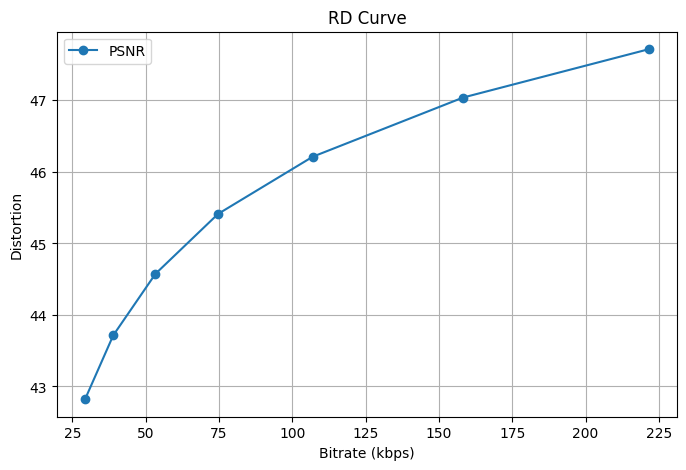

In [37]:
import matplotlib.pyplot as plt

grouped = df.groupby('qp').agg({
    'bitrate': 'mean',
    'psnr': 'mean',
    'ssim': 'mean'
}).reset_index()

plt.figure(figsize=(8, 5))
plt.plot(grouped['bitrate'], grouped['psnr'], marker='o', label='PSNR')
# plt.plot(grouped['bitrate'], grouped['ssim'], marker='s', label='SSIM')
plt.xlabel('Bitrate (kbps)')
plt.ylabel('Distortion')
plt.title('RD Curve')
plt.legend()
plt.grid(True)
plt.show()